# Set Environment

In [9]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')

### directory
DAT_DIR = "/data/clintko/flow_EQAPOL_normal"

In [10]:
%matplotlib inline

In [11]:
def generate_sample(mean, cov, num_events):
    """......"""
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[0] == num_events.shape[0]
    
    num_clusters = mean.shape[0]
    dat = [np.random.multivariate_normal(mean[idx], cov[idx], num_events[idx]) for idx in range(num_clusters)]
    dat = np.concatenate(dat)
    return dat

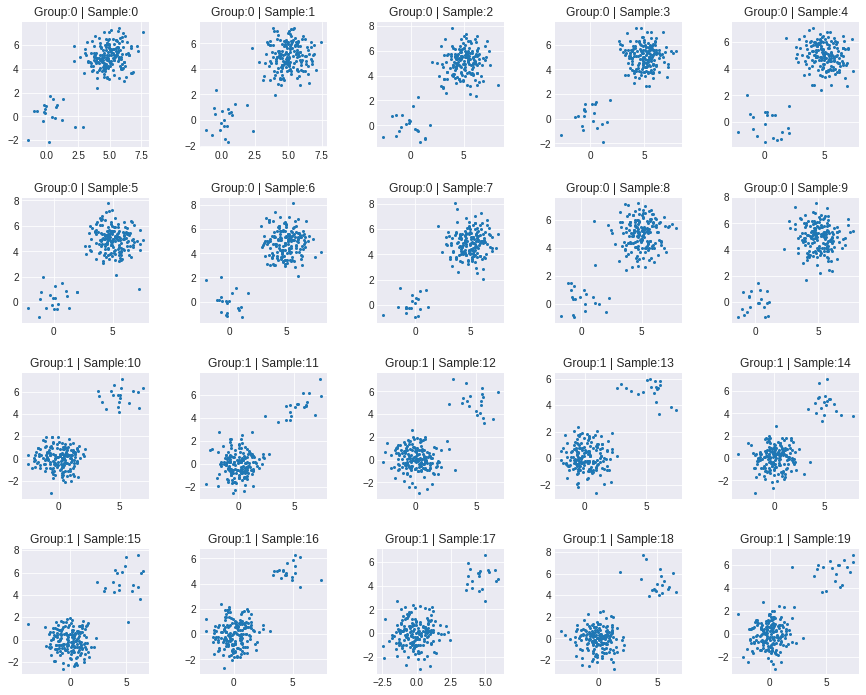

In [12]:
### Generate data
mu1 = np.array([[0, 0],[5, 5]])        ### Mean
sd1 = np.array([np.eye(2), np.eye(2)]) ### SD
nc1 = np.array([20, 180])             ### number of cells
ns1 = 10                               ### number of samples
y1  = np.array([generate_sample(mu1, sd1, nc1) for _ in range(ns1)])

mu2 = np.array([[0, 0],[5, 5]])        ### Mean
sd2 = np.array([np.eye(2), np.eye(2)]) ### SD
nc2 = np.array([180, 20])             ### number of cells
ns2 = 10                               ### number of samples
y2  = np.array([generate_sample(mu2, sd2, nc2) for _ in range(ns2)])

mu3 = np.array([[0, 0],[5, 5]])        ### Mean
sd3 = np.array([np.eye(2), np.eye(2)]) ### SD
nc3 = np.array([180, 20])             ### number of cells
ns3 = 10                               ### number of samples
y3  = np.array([generate_sample(mu3, sd3, nc3) for _ in range(ns3)])

### combine the samples and set labels
matrix = np.concatenate([y1, y2, y3])
label  = [0] * ns1 + [1] * ns2 + [2] * ns3

### visualization
fig, axes = plt.subplots(ncols=5, nrows=4, figsize = (3*5, 3*4))
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    ax.scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
    ax.set_title("Group:" + str(label[idx]) + " | Sample:" + str(idx))

In [13]:
### wrap up the data
print("STEP: wrap up the data")
print("+++++++++++++++++++++++++++++++++++")
%time dat_wrap = Data_Wrapper(matrix, label)
print(dat_wrap)

STEP: wrap up the data
+++++++++++++++++++++++++++++++++++
CPU times: user 1.26 ms, sys: 1 ms, total: 2.26 ms
Wall time: 617 µs
Label: Counter({0: 10, 1: 10, 2: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
    2: [20 21 22 23 24 25 26 27 28 29]
------------------
Data Matrix: (6000, 2)
    #Samples:   30
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [14]:
### Standardize the data
print("STEP: Standardize the data")
print("+++++++++++++++++++++++++++++++++++")
scaler = Transform_StandardScaler(k = 0)
scaler = scaler.fit(dat_wrap)
%time dat_scaled = scaler.transform(dat_wrap)
print(dat_scaled)

STEP: Standardize the data
+++++++++++++++++++++++++++++++++++
Transform_StandardScaler(k=0)
Total Sample: 30
Standardized based on sample: 0

***** k_th Sample: 0 *****
Mean:
[4.45376592 4.58656786]
SD:
[1.67329743 1.76274601]

CPU times: user 493 µs, sys: 393 µs, total: 886 µs
Wall time: 772 µs
Label: Counter({0: 10, 1: 10, 2: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
    2: [20 21 22 23 24 25 26 27 28 29]
------------------
Data Matrix: (6000, 2)
    #Samples:   30
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [15]:
### Subsetting
print("STEP: Subsetting")
print("+++++++++++++++++++++++++++++++++++")
sampler = Transform_Subsampling(n_subsample = 5, n_size = 100, random_state = 123)
%time dat_subs = sampler.fit_transform(dat_scaled)
print(dat_subs)

STEP: Subsetting
+++++++++++++++++++++++++++++++++++
CPU times: user 2.52 ms, sys: 0 ns, total: 2.52 ms
Wall time: 2.28 ms
Label: Counter({0: 50, 1: 50, 2: 50})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
    1: [50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]
    2: [100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]
------------------
Data Matrix: (15000, 2)
    #Samples:   150
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [16]:
### Dimensional Reduction: t-SNE
print("STEP: Dim.Reduct.")
print("+++++++++++++++++++++++++++++++++++")
tsne = Transform_TSNE(n_components = 2, n_jobs = 12, random_state = 123)
%time dat_tsne = tsne.transform(dat_subs, verbose=True)
print(dat_tsne)

STEP: Dim.Reduct.
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86

In [17]:
### Kernel Density estimation
print("STEP: Kernel Density estimation")
print("+++++++++++++++++++++++++++++++++++")
density = Transform_Density(sig2 = 5)
%time dat_img = density.transform(dat_tsne, verbose=True)
print(dat_img)

STEP: Kernel Density estimation
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample:

In [18]:
### Perform PCA and logistic regression
print("STEP: Perform PCA and logistic regression")
print("+++++++++++++++++++++++++++++++++++")
pca_logreg = Classify_PCA_LogReg(dat_img, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img)
print(pca_logreg)

STEP: Perform PCA and logistic regression
+++++++++++++++++++++++++++++++++++
PCA explained ratio:    0.912
PCA num components:     5
Original    data shape: (150, 32768)
PCA reduced data shape: (150, 5)
Log.Reg. Accuracy:      0.76
CPU times: user 9.09 s, sys: 6.99 s, total: 16.1 s
Wall time: 845 ms
Classify_PCA_LogReg(dat=None, pca_explained_ratio=None)


In [21]:
print(pca_logreg.model.coef_.shape)
pca_logreg.model.coef_

(3, 5)


array([[ 1.25998677e-02, -2.52976611e-04, -3.31716330e-04,
         1.12914241e-03, -8.51454675e-04],
       [-7.32913131e-04,  6.72353147e-05,  3.80897340e-04,
        -3.85060976e-04,  5.53229405e-04],
       [-5.94567136e-04,  2.02479559e-05, -3.60560558e-04,
         2.54892294e-04, -5.48253828e-04]])

In [23]:
print(pca_logreg.X_red.shape)
print(pca_logreg.y)

(150, 5)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [30]:
from sklearn.metrics import roc_curve, auc

In [39]:
print(y_test.shape)
print(y_score.shape)

(150, 3)
(150, 3)


In [44]:
clf = OneVsRestClassifier(pca_logreg.model)
X = pca_logreg.X_red
y = to_categorical(pca_logreg.y)
n_classes = 3

X_train = X; X_test = X
y_train = y; y_test = y


y_score = clf.fit(X_train, y_train).decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

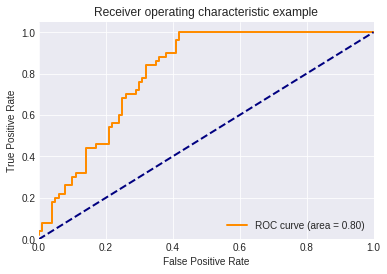

In [48]:
plt.figure()
lw = 2
plt.plot(fpr[2], tpr[2], color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

# Visualization